# Agent-1: Choi 표현의 이론적 기초

이 노트북은 finite-dimensional quantum channel을 나타내는 네 가지 표준 표현, 즉 Kraus 표현, Choi 표현, Stinespring 표현, natural/Liouville 표현을 설명한다. 프로젝트 전체에서 사용하는 Choi convention은 다음과 같다.

$$C_{\mathcal{E}} = \sum_{i,j} |i\rangle\langle j| \otimes \mathcal{E}(|i\rangle\langle j|).$$

이 convention에서는 input system이 첫 번째 tensor factor이고, output system이 두 번째 tensor factor이다. 이 순서는 이후 process tomography, SDP channel discrimination, quantum comb, interactive widget에서도 동일하게 사용된다.

참고문헌: Nielsen and Chuang, Chapter 8; Watrous, Chapter 2; Wilde, Chapter 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from choi_common.channels import (
    amplitude_damping_channel,
    bit_flip_channel,
    depolarizing_channel,
    identity_channel,
    pauli_channel,
    phase_damping_channel,
    phase_flip_channel,
)
from choi_common.representations import (
    apply_kraus_channel,
    choi_to_kraus,
    choi_to_natural,
    compose_choi_channels,
    kraus_to_choi,
    kraus_to_stinespring,
    natural_to_choi,
    stinespring_to_kraus,
)
from choi_common.validation import choi_rank, is_cp, is_tp, is_unital
from channel_reps import random_channel

np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)

PALETTE = {
    "blue": "#1f77b4",
    "orange": "#ff7f0e",
    "green": "#2ca02c",
    "red": "#d62728",
    "purple": "#9467bd",
    "gray": "#7f7f7f",
}


<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 필요한 module과 helper function을 import하고 random seed를 고정한다. 출력이 없는 것이 정상이다. 이후 셀에서 사용하는 standard channel constructor와 representation conversion function이 모두 준비된 상태가 된다.

## 1. Channel Representations

Quantum channel은 density matrix를 다른 density matrix로 보내는 물리적인 선형 map이다. 같은 channel이라도 계산 목적에 따라 여러 표현을 사용할 수 있다. 이 노트북에서는 Kraus operators, Choi matrix, Stinespring isometry, natural superoperator를 차례로 다룬다.

아래 예시는 모두 one-qubit channel이다. 따라서 input dimension과 output dimension이 모두 2이고, 각 Choi matrix는 `4 x 4` 행렬이 된다.

In [2]:
def summarize_channel(name, kraus_ops):
    choi = kraus_to_choi(kraus_ops)
    eigvals = np.linalg.eigvalsh(choi)
    print(f"\n{name}")
    print("Choi matrix:")
    print(choi)
    print(f"CP={is_cp(choi)}, TP={is_tp(choi, d_in=2)}, rank={choi_rank(choi)}")
    print(f"eigenvalues={np.round(eigvals, 6)}")
    return choi

examples = {
    "identity": identity_channel(2),
    "bit flip p=0.2": bit_flip_channel(0.2),
    "phase flip p=0.2": phase_flip_channel(0.2),
    "depolarizing p=0.3": depolarizing_channel(0.3),
    "amplitude damping gamma=0.3": amplitude_damping_channel(0.3),
    "phase damping gamma=0.3": phase_damping_channel(0.3),
}

choi_examples = {name: summarize_channel(name, kraus) for name, kraus in examples.items()}



identity
Choi matrix:
[[1.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 1.+0.j]]
CP=True, TP=True, rank=1
eigenvalues=[0. 0. 0. 2.]

bit flip p=0.2
Choi matrix:
[[0.8+0.j 0. +0.j 0. +0.j 0.8+0.j]
 [0. +0.j 0.2+0.j 0.2+0.j 0. +0.j]
 [0. +0.j 0.2+0.j 0.2+0.j 0. +0.j]
 [0.8+0.j 0. +0.j 0. +0.j 0.8+0.j]]
CP=True, TP=True, rank=2
eigenvalues=[-0.   0.   0.4  1.6]

phase flip p=0.2
Choi matrix:
[[1. +0.j 0. +0.j 0. +0.j 0.6+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.6+0.j 0. +0.j 0. +0.j 1. +0.j]]
CP=True, TP=True, rank=2
eigenvalues=[0.  0.  0.4 1.6]

depolarizing p=0.3
Choi matrix:
[[0.85+0.j 0.  +0.j 0.  +0.j 0.7 +0.j]
 [0.  +0.j 0.15+0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.15+0.j 0.  +0.j]
 [0.7 +0.j 0.  +0.j 0.  +0.j 0.85+0.j]]
CP=True, TP=True, rank=4
eigenvalues=[0.15 0.15 0.15 1.55]

amplitude damping gamma=0.3
Choi matrix:
[[1.   +0.j 0.   +0.j 0.   +0.j 0.837+0.j]
 [0.   +0.j

<!-- 실행 결과 해설 -->
### 실행 결과 해설

각 standard channel에 대해 Choi matrix, CP/TP 여부, Choi rank, eigenvalue가 출력된다. Identity channel의 rank가 1인 것은 하나의 Kraus operator, 즉 identity operator만으로 표현되기 때문이다. Bit flip, depolarizing, amplitude damping 같은 noisy channel은 여러 Kraus branch를 가지므로 rank가 증가한다.

`CP=True`, `TP=True`는 출력된 channel들이 physical quantum channel임을 확인한다. Eigenvalue가 음수가 아니면 CP 조건을 만족하고, partial trace가 identity이면 TP 조건을 만족한다. 이 표는 Choi matrix가 channel의 물리적 가능성과 구조적 복잡도를 한 번에 보여 준다는 점을 확인하는 첫 번째 sanity check이다.

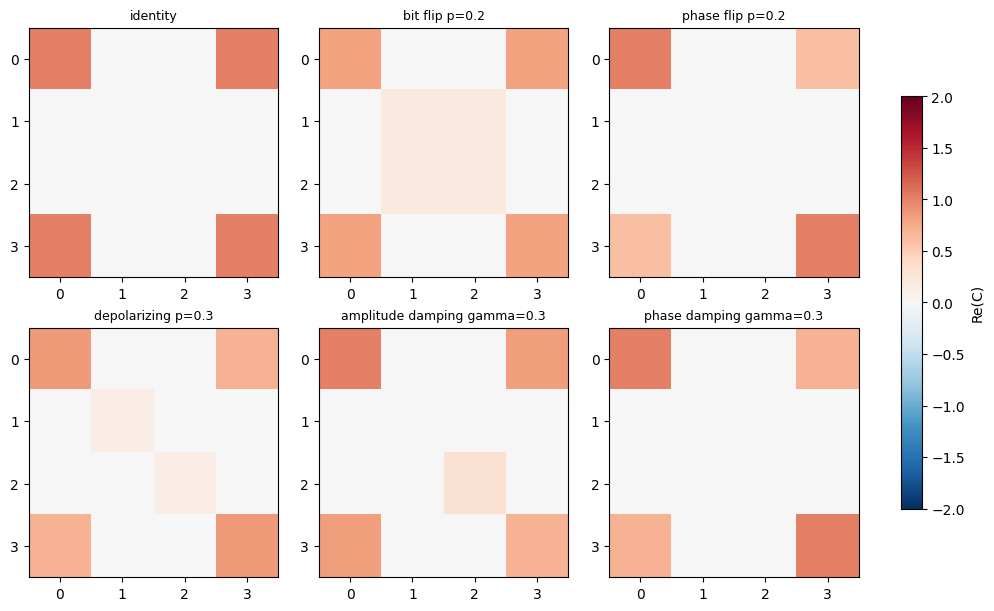

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
for ax, (name, choi) in zip(axes.ravel(), choi_examples.items()):
    im = ax.imshow(np.real(choi), cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_title(name, fontsize=9)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, label="Re(C)")
plt.show()


<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 그림은 여러 표준 qubit channel의 Choi matrix를 heatmap으로 비교한다. Identity channel은 maximally entangled structure가 뚜렷하게 나타나고, depolarizing이나 damping channel은 noise가 추가되면서 diagonal/off-diagonal 구조가 달라진다. 같은 `4 x 4` Choi matrix라도 channel 종류에 따라 패턴이 다르다는 점을 시각적으로 보여 준다.

## 2. Choi-Jamiołkowski Isomorphism

Choi-Jamiołkowski isomorphism은 linear map을 하나의 matrix로 바꾸는 대응이다. 직관적으로는 unnormalized maximally entangled operator의 한쪽 절반에 channel을 적용한 결과를 모아 Choi matrix를 만든다고 볼 수 있다.

좌표로 쓰면 `C`의 각 block은 matrix unit `|i><j|`에 channel을 적용한 출력이다. 반대로 positive Choi matrix가 주어지면 eigen-decomposition을 통해 Kraus operator를 복원할 수 있다. 만약 `C = sum_r lambda_r |v_r><v_r|`라면, 각 `sqrt(lambda_r) v_r`를 적절한 행렬 모양으로 reshape하여 Kraus operator를 얻는다.

In [4]:
random_kraus = random_channel(d_in=2, d_out=2, n_kraus=3)
random_choi = kraus_to_choi(random_kraus)
recovered_kraus = choi_to_kraus(random_choi)

psi = np.array([1, 1j], dtype=complex)
psi = psi / np.linalg.norm(psi)
rho = np.outer(psi, psi.conj())
out_original = apply_kraus_channel(rho, random_kraus)
out_recovered = apply_kraus_channel(rho, recovered_kraus)

print("Recovered Kraus count:", len(recovered_kraus))
print("Choi rank:", choi_rank(random_choi))
print("||E(rho) - E_recovered(rho)||_F =", np.linalg.norm(out_original - out_recovered))
print("CP:", is_cp(random_choi), "TP:", is_tp(random_choi, d_in=2))


Recovered Kraus count: 3
Choi rank: 3
||E(rho) - E_recovered(rho)||_F = 2.5561758366887023e-16
CP: True TP: True


<!-- 실행 결과 해설 -->
### 실행 결과 해설

Random channel에서 Choi matrix를 만든 뒤 eigen-decomposition으로 Kraus operator를 복원한다. `Recovered Kraus count`와 `Choi rank`가 일치하는 것은 Choi rank가 최소 Kraus count와 연결된다는 이론을 수치적으로 확인한 것이다.

`||E(rho) - E_recovered(rho)||_F` 값이 `1e-16` 수준으로 매우 작다. 이는 원래 Kraus representation으로 적용한 channel과, Choi matrix에서 복원한 Kraus representation으로 적용한 channel이 machine precision 내에서 같다는 뜻이다. `CP: True TP: True`는 random channel 생성 과정이 physical channel을 만들었음을 확인한다.

## 3. Choi Matrix가 보여 주는 성질

이 프로젝트의 input-first convention에서는 complete positivity가 `C >= 0`과 동치이다. Trace preservation은 output subsystem에 대한 partial trace 조건 `Tr_output(C) = I_input`과 동치이다. 또한 `C`의 numerical rank는 필요한 Kraus operator의 최소 개수, 즉 Choi rank를 알려 준다.

Square channel의 경우 unitality는 input subsystem에 대한 partial trace 조건 `Tr_input(C) = I_output`으로 확인할 수 있다.

In [5]:
for name in ["depolarizing p=0.3", "amplitude damping gamma=0.3"]:
    choi = choi_examples[name]
    print(f"{name}: min eigenvalue={np.min(np.linalg.eigvalsh(choi)):.6g}, ", end="")
    print(f"TP={is_tp(choi, 2)}, unital={is_unital(choi, 2)}, Choi rank={choi_rank(choi)}")

bad_choi = choi_examples["identity"].copy()
bad_choi[0, 0] = -0.1
print("Perturbed identity Choi is CP:", is_cp(bad_choi))


depolarizing p=0.3: min eigenvalue=0.15, TP=True, unital=True, Choi rank=4
amplitude damping gamma=0.3: min eigenvalue=0, TP=True, unital=False, Choi rank=2
Perturbed identity Choi is CP: False


<!-- 실행 결과 해설 -->
### 실행 결과 해설

Depolarizing channel은 `TP=True`, `unital=True`로 출력된다. 이는 maximally mixed state를 그대로 유지하는 unital channel이라는 뜻이다. Amplitude damping channel은 `TP=True`이지만 `unital=False`이다. 이는 trace는 보존하지만 maximally mixed state를 그대로 두지는 않고, Bloch sphere를 특정 방향으로 이동시키는 relaxation 성격을 갖기 때문이다.

마지막의 perturbed identity Choi가 `CP: False`인 것은 Choi matrix에 작은 비물리적 perturbation을 넣으면 eigenvalue가 음수가 되어 complete positivity가 깨질 수 있음을 보여 준다.

Entanglement-breaking channel은 normalized Choi state가 input-output 분할에 대해 separable인 channel과 정확히 대응한다. 완전한 separability test는 이 폴더의 dependency 범위를 넘기 때문에 여기서는 구현하지 않는다. 대신 completely depolarizing qubit channel의 Choi state가 `I/2 \otimes I` 형태로 separable하다는 점을 교육용 special case로 확인한다.

In [6]:
completely_depolarizing = depolarizing_channel(1.0)
C_dep = kraus_to_choi(completely_depolarizing)
print("Completely depolarizing Choi / d_in:")
print(C_dep / 2)
print("This normalized Choi state has maximally mixed output blocks and is separable for the qubit depolarizing endpoint.")


Completely depolarizing Choi / d_in:
[[0.25+0.j 0.  +0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.25+0.j 0.  +0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.25+0.j 0.  +0.j]
 [0.  +0.j 0.  +0.j 0.  +0.j 0.25+0.j]]
This normalized Choi state has maximally mixed output blocks and is separable for the qubit depolarizing endpoint.


<!-- 실행 결과 해설 -->
### 실행 결과 해설

Completely depolarizing channel의 normalized Choi state가 `I/2 tensor I/2`와 같은 maximally mixed product form으로 출력된다. Product form은 input-output 사이 entanglement가 없다는 뜻이며, 이 special case는 entanglement-breaking channel의 직관을 준다. 즉 channel이 입력 정보를 완전히 지우면 normalized Choi state도 separable한 구조가 된다.

## 4. 표현 사이의 변환

이 모듈은 직접 변환으로 `Kraus <-> Choi`, `Kraus <-> Stinespring`, `Choi <-> Natural`을 구현한다. 나머지 표현 쌍 사이의 변환은 이 직접 변환들을 합성해서 얻을 수 있다.

Natural representation은 column-stacking vectorization을 사용한다. 즉 `vec(E(rho)) = S vec(rho)`가 되도록 channel을 superoperator matrix `S`로 나타낸다.

In [7]:
kraus = random_channel(d_in=2, d_out=3, n_kraus=2)
choi = kraus_to_choi(kraus)
natural = choi_to_natural(choi)
choi_again = natural_to_choi(natural)
stinespring = kraus_to_stinespring(kraus)
kraus_again = stinespring_to_kraus(stinespring, env_dim=2)

print("Non-square Choi shape:", choi.shape)
print("Natural shape:", natural.shape)
print("Stinespring isometry shape:", stinespring.shape)
print("Choi <-> Natural error:", np.linalg.norm(choi - choi_again))
print("Kraus <-> Stinespring block error:", sum(np.linalg.norm(a - b) for a, b in zip(kraus, kraus_again)))


Non-square Choi shape: (6, 6)
Natural shape: (9, 4)
Stinespring isometry shape: (6, 2)
Choi <-> Natural error: 0.0
Kraus <-> Stinespring block error: 0.0


<!-- 실행 결과 해설 -->
### 실행 결과 해설

이 셀은 input dimension과 output dimension이 다른 non-square channel 예제를 사용한다. `Non-square Choi shape: (6, 6)`은 `d_in=2`, `d_out=3`인 channel의 Choi matrix 크기가 `2*3` by `2*3`이 됨을 의미한다. `Natural shape: (9, 4)`는 vectorized input density matrix 크기 4에서 vectorized output density matrix 크기 9로 가는 superoperator라는 뜻이다.

두 conversion error가 0에 가까운 것은 `Choi <-> Natural`, `Kraus <-> Stinespring` 변환이 이 예제에서 정확히 round-trip된다는 의미이다.

## 5. Composition과 Channel Algebra

Natural form에서는 channel composition이 ordinary matrix multiplication이 된다. 즉 `S_{E2 o E1} = S_E2 S_E1`이다. Choi link product도 본질적으로 같은 연산이지만, Choi index와 natural index 사이의 reshuffling을 거쳐 표현된다.

이 노트북에서는 `compose_choi_channels`를 통해 Choi representation 위에서 안전하게 channel composition을 수행한다.

In [8]:
p = 0.2
q = 0.3
C1 = kraus_to_choi(bit_flip_channel(p))
C2 = kraus_to_choi(bit_flip_channel(q))
C_composed = compose_choi_channels(choi_after=C2, choi_before=C1)

expected_p = p + q - 2 * p * q
C_expected = kraus_to_choi(bit_flip_channel(expected_p))

print("Expected composed bit-flip probability:", expected_p)
print("Composition error:", np.linalg.norm(C_composed - C_expected))
print("CP:", is_cp(C_composed), "TP:", is_tp(C_composed, d_in=2))


Expected composed bit-flip probability: 0.38
Composition error: 2.482534153247273e-16
CP: True TP: True


<!-- 실행 결과 해설 -->
### 실행 결과 해설

두 bit-flip channel을 연속으로 적용하면 effective bit-flip probability가 단순히 `p+q`가 아니라 `p(1-q)+(1-p)q` 형태가 된다. 출력의 expected probability `0.38`은 이 classical parity logic과 일치한다.

`Composition error`가 `1e-16` 수준이므로 natural form을 통한 composition과 analytic expectation이 machine precision 내에서 같다는 뜻이다. 마지막 `CP: True TP: True`는 composed channel도 여전히 physical channel임을 확인한다.